In [111]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random

from hydrosense.database.bigquery import load_plean, info_piezo
from hydrosense.params import *

In [112]:
len(TARGETS_BSS)

19

In [113]:
DATA_CODE_PIEZO = "BSS001QHYH"
DATA_CODE_PIEZO = TARGETS_BSS[random.randint(0,len(TARGETS_BSS))]
print(DATA_CODE_PIEZO)

df_plean = load_plean(DATA_CODE_PIEZO)

BSS001SHNE
✅ BSS001SHNE : 8888 lignes de features ML chargées.


In [114]:
info = info_piezo(DATA_CODE_PIEZO)
info[['p5_global','p10_global','p20_global']].values
info

/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,altitude_station,bss_id,code_departement,codes_bdlisa,codes_masse_eau_edl,date_debut_mesure,date_fin_mesure,nb_mesures_piezo,nom_commune,profondeur_investigation,...,niveau_median,niveau_std,total_jours_manquants,taux_completude,p95_global,p85_global,p50_global,p20_global,p10_global,p5_global
0,21.94,BSS001SHNE,17,348AA03,FG093,1992-07-23 00:00:00+00:00,2026-05-27 00:00:00+00:00,12118,Saint-Agnant,101.0,...,5.87,1.699269,244,98.03,6.14,4.89,4.73,4.6,4.34,4.18


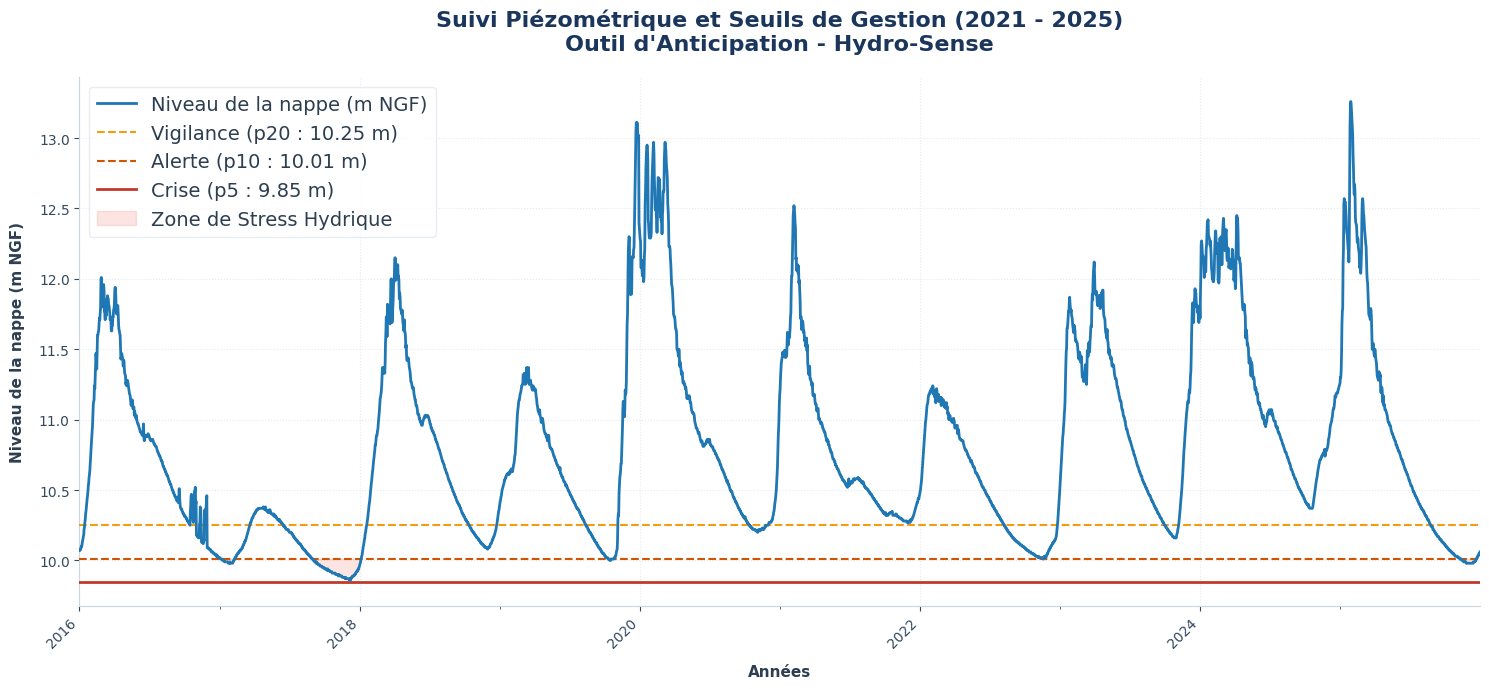

In [ ]:
# Aligner et filtrer la période d'étude
start_date = '2016-01-01'
end_date = '2025-12-31'

df_filtered = df_plean.set_index(DATE_COL)
df_filtered = df_filtered.loc[start_date:end_date]

seuil_crise = float(info['p5_global'].iloc[0])
seuil_alerte = float(info['p10_global'].iloc[0])
seuil_vigilance = float(info['p20_global'].iloc[0])

# ---  Configuration de la Figure ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#2c3e50'
plt.rcParams['axes.labelcolor'] = '#2c3e50'
fig, ax = plt.subplots(figsize=(15, 7))

# ---  Tracé de la Chronique Piézométrique ---
ax.plot(df_filtered.index, df_filtered[TARGET_COL],
        color='#1f77b4', linewidth=2, label='Niveau de la nappe (m NGF)', zorder=4)

ax.axhline(y=seuil_vigilance, color='#f39c12', linestyle='--', linewidth=1.5,
           label=f'Vigilance (p20 : {seuil_vigilance} m)', zorder=3)
ax.axhline(y=seuil_alerte, color='#d35400', linestyle='--', linewidth=1.5,
           label=f'Alerte (p10 : {seuil_alerte} m)', zorder=3)
ax.axhline(y=seuil_crise, color='#c0392b', linestyle='-', linewidth=2,
           label=f'Crise (p5 : {seuil_crise} m)', zorder=3)

# --- LA CORRECTION : Créer un vecteur de constantes de la taille de ton index ---
seuil_alerte_series = pd.Series(seuil_alerte, index=df_filtered.index)

# --- TRACÉ : Utilise cette série à la place de la constante brute ---
ax.fill_between(
    df_filtered.index,
    df_filtered[TARGET_COL],       # Borne 1 : Ta courbe piézométrique
    seuil_alerte_series,            # Borne 2 : La ligne du seuil d'alerte
    where=(df_filtered[TARGET_COL] <= seuil_alerte_series), # Condition jour par jour
    color='#e74c3c',
    alpha=0.15,
    label='Zone de Stress Hydrique',
    zorder=2
)
# --- 7. Habillage et Design Épuré ---
ax.set_title(f"Suivi Piézométrique et Seuils de Gestion (2021 - 2025)\nOutil d'Anticipation - Hydro-Sense",
             fontsize=16, fontweight='bold', color='#1a365d', pad=20)
ax.set_ylabel("Niveau de la nappe (m NGF)", fontweight='bold', fontsize=11, labelpad=10)
ax.set_xlabel("Années", fontweight='bold', fontsize=11, labelpad=10)

# Grille discrète
ax.grid(True, linestyle=':', alpha=0.5, color='#cbd5e1')

# Nettoyage des bordures (Spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cbd5e1')
ax.spines['bottom'].set_color('#cbd5e1')

# 1. Positionnement des repères principaux (Tous les 2 ans, calés au 1er janvier)
ax.xaxis.set_major_locator(mdates.YearLocator(2, month=1, day=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1, month=1, day=1))
# rotation=45 permet de gagner de l'espace, ha='right' aligne le haut du texte sous le trait de repère
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_xlim(df_filtered.index.min(), df_filtered.index.max())
# Légende élégante en dehors ou dans un coin vide
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e2e8f0', shadow=False,
          fontsize=14)

# Ajustement des marges
plt.tight_layout()
plt.show()

In [86]:
df_filtered[TARGET_COL] <= seuil_alerte

ValueError: ('Lengths must match to compare', (6764,), (1,))

## 3. La Recherche du "Temps de Réponse" (Cross-Correlation)

L'eau met du temps à s'infiltrer à travers le sol pour atteindre l'aquifère. S'il pleut aujourd'hui, le niveau de la nappe ne montera peut-être que dans 10, 20 ou 40 jours.

Calculer la corrélation croisée (Lags) pour trouver le délai de recharge.

### 1. Le "Sanity Check" (L'état des lieux)

Regarder la complétude et la distribution des données synthétiques.

In [8]:

print("Valeurs manquantes par colonne :")
print(df_plean.isna().sum())

print("\nStatistiques descriptives :")
print(df_plean[['RR_synth', 'PU_synth', 'niveau_nappe_eau']].describe())


Valeurs manquantes par colonne :
bss_id               0
date_mesure          0
niveau_nappe_eau     0
RR_synth             0
TM_synth             4
FFM_synth           27
PU_synth             0
PC1                  0
PC2                  0
PC3                  0
dtype: int64

Statistiques descriptives :
           RR_synth      PU_synth  niveau_nappe_eau
count  11821.000000  11821.000000      11821.000000
mean       2.293287     -0.656673         12.234179
std        5.015381      5.183032          1.180228
min        0.000000     -7.261000          7.370000
25%        0.000000     -3.508000         11.710000
50%        0.190000     -1.881000         12.470000
75%        2.000000     -0.449000         12.970000
max       61.600000     56.758000         14.620000


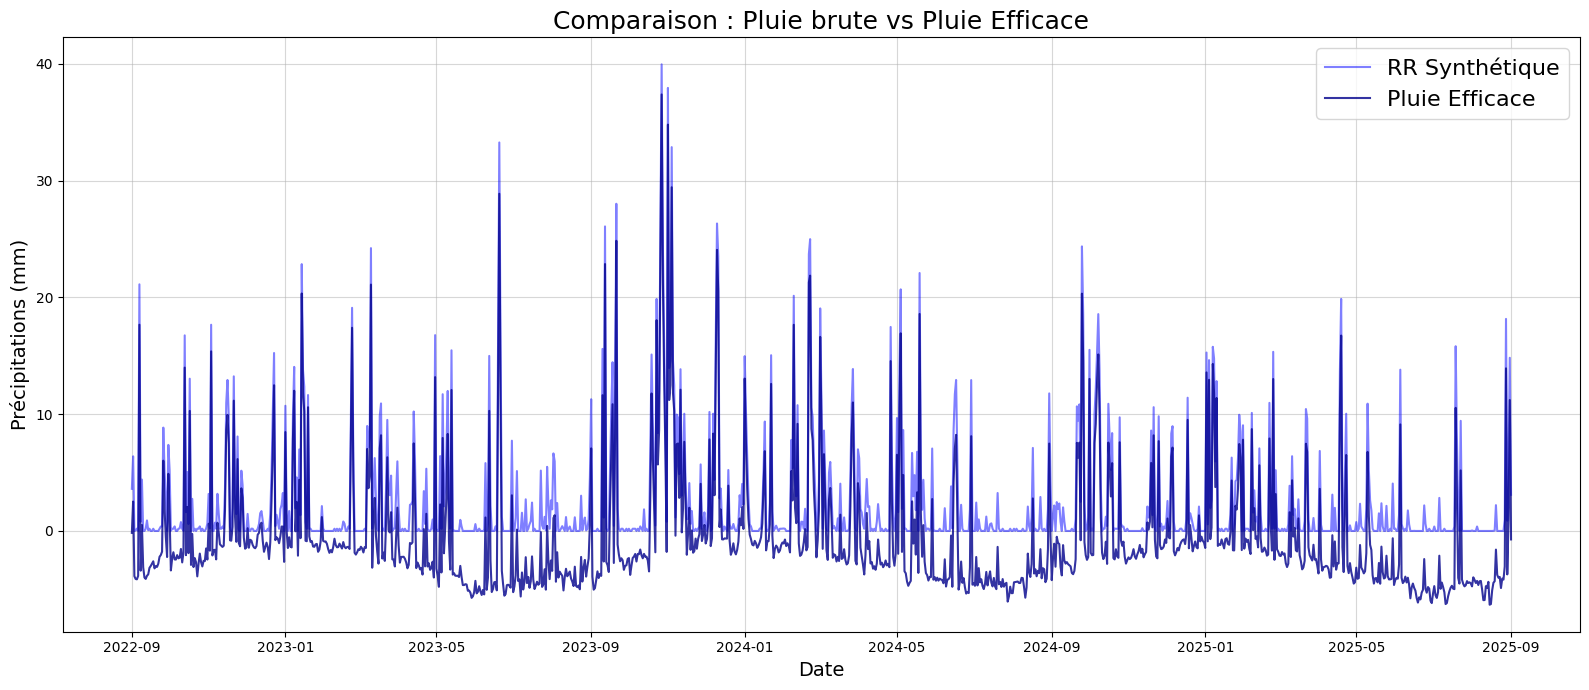

In [ ]:
start_date = '2022-09-01'
end_date = '2025-09-01'


mask = (df_plean['date_mesure'] >= start_date) & (df_plean['date_mesure'] <= end_date)
df_zoom = df_plean.loc[mask]

# 2. Identification des colonnes
cols_rr = [c for c in df_plean.columns if ('RR_' in c and c[-1].isnumeric())]
col_synth = 'RR_synth'


plt.figure(figsize=(16, 7))
for col in cols_rr:
    plt.plot(df_zoom['date_mesure'], df_zoom[col], alpha=0.5, linestyle='--', label=f"Station {col.split('_')[1]}")

# Tracé de la synthèse avec une ligne plus épaisse et colorée
plt.plot(df_zoom['date_mesure'], df_zoom[col_synth], alpha = 0.5, color='blue', linewidth=1.5, label='RR Synthétique')
plt.plot(df_zoom['date_mesure'], df_zoom['PU_synth'], alpha = 0.8, color='darkblue', linewidth=1.5, label='Pluie Efficace')



plt.title(f"Comparaison : Pluie brute vs Pluie Efficace", fontsize=18)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Précipitations (mm)", fontsize=14)
plt.legend(loc='upper right', fontsize = 16)
plt.grid(True, alpha=0.5)
plt.tight_layout()

## 2. L'Hydrogramme Pluie-Niveau

En hydrogéologie, l'hydrogramme avec les précipitations inversées en haut (qui "tombent" vers le bas) et le niveau de la nappe en bas. C'est ce qui permet de voir "à l'œil nu" si la nappe réagit vite aux épisodes pluvieux.

Créer un graphique à double axe

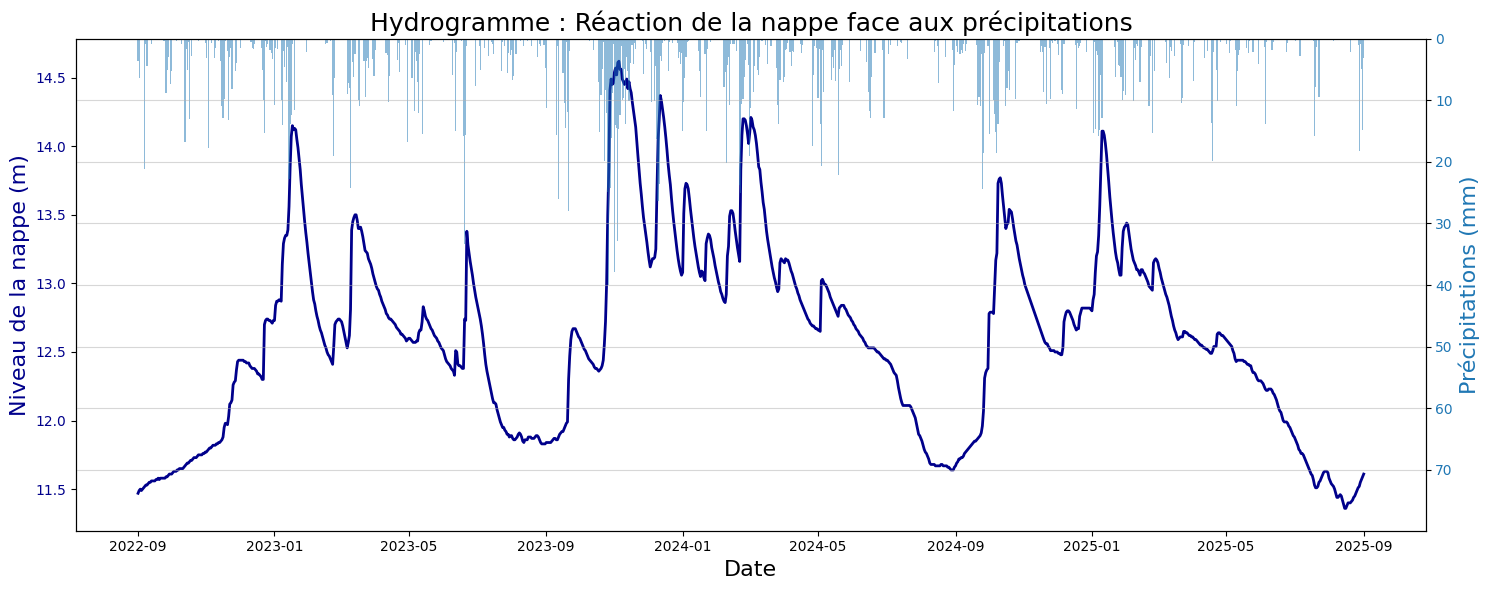

In [23]:



df_zoom = df_plean[(df_plean['date_mesure'] >= start_date) & (df_plean['date_mesure'] <= end_date)]
fig, ax1 = plt.subplots(figsize=(15, 6))

color = 'darkblue'
ax1.set_xlabel('Date',  fontsize = 16)
ax1.set_ylabel('Niveau de la nappe (m)', color=color, fontsize = 16)
ax1.plot(df_zoom['date_mesure'], df_zoom['niveau_nappe_eau'], color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# La pluie synthétique (en gris/bleu clair, inversé)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Précipitations (mm)', color=color, fontsize = 16)
ax2.bar(df_zoom['date_mesure'], df_zoom['RR_synth'], color=color, alpha=0.5, width=1)
ax2.tick_params(axis='y', labelcolor=color)

# On inverse l'axe des ordonnées pour la pluie (effet "chute d'eau")
ax2.set_ylim(ax2.get_ylim()[::-1])
ax2.set_ylim(df_zoom['RR_synth'].max()*2, 0)

plt.title("Hydrogramme : Réaction de la nappe face aux précipitations", fontsize = 18)
plt.grid(True, alpha = 0.5)
fig.tight_layout()
plt.show()

## 3. La Recherche du "Temps de Réponse" (Cross-Correlation)

L'eau met du temps à s'infiltrer à travers le sol pour atteindre l'aquifère. S'il pleut aujourd'hui, le niveau de la nappe ne montera peut-être que dans 10, 20 ou 40 jours.

Calculer la corrélation croisée (Lags) pour trouver le délai de recharge.

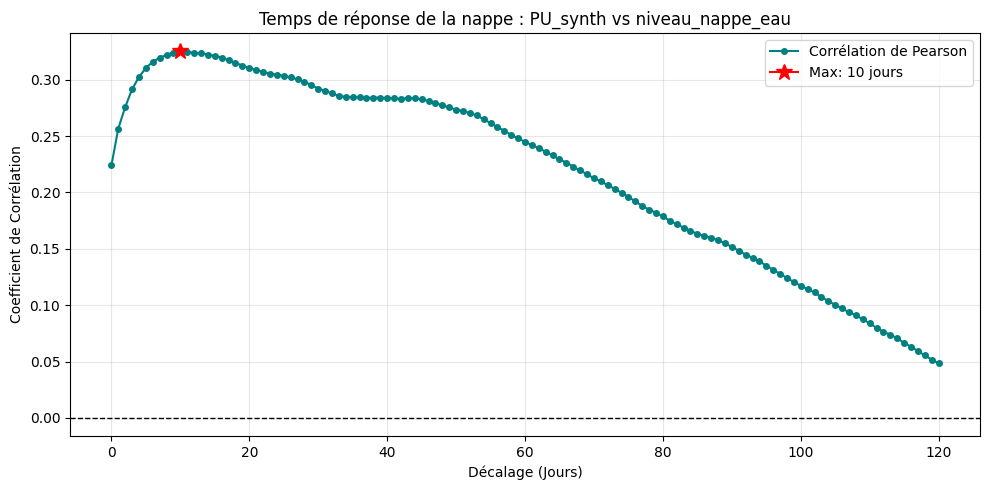

✅ Le temps de réponse optimal estimé de la nappe est de 10 jours (Corrélation: 0.325).


(10, np.float64(0.32529300572844183))

In [25]:
from hydrosense.utils.evap import lag_pluie

lag_pluie(df_plean, toggle_plot =  True
                           )

### Heatmap

Visualisation des corrélations des features.

In [34]:
from hydrosense.preprocess.preprocessor import preprocess_week, prepare_lags


,niveau_nappe_eau,PU_synth,PC1,PC2,PC3
niveau_nappe_eau,1.000000,0.071714,0.936714,-0.134906,-0.114439
PU_synth,0.071714,1.000000,0.036889,0.143190,0.181185
PC,0.936714,0.036889,1.000000,-0.001842,-0.006732
PC2,-0.134906,0.143190,-0.001842,1.000000,-0.004859
PC3,-0.114439,0.181185,-0.006732,-0.004859,1.000000



⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 934 semaines | 10 colonnes



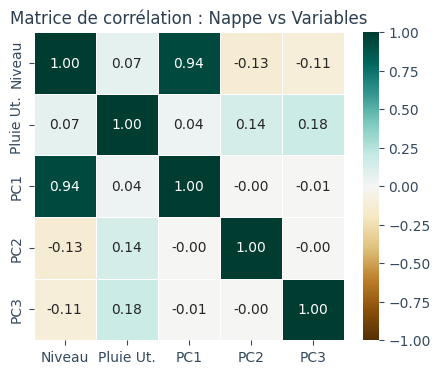

In [110]:
# 1. Calcul de la matrice de corrélation
# On sélectionne uniquement les colonnes numériques pertinentes
df_plean = preprocess_week(df_plean)


cols_to_corr =  ['niveau_nappe_eau', 'PU_synth', 'PC1', 'PC2', 'PC3']
corr_mat = df_plean[cols_to_corr].corr()
corr_mat = corr_mat.rename(columns={'niveau_nappe_eau':'Niveau','PU_synth':'Pluie Ut.'} )
corr_mat = corr_mat.rename(index={'niveau_nappe_eau':'Niveau','PU_synth':'Pluie Ut.'} )

# 2. Configuration de la figure
plt.figure(figsize=(5, 4))

# 3. Création de la Heatmap
sns.heatmap(
    corr_mat,
    vmin=-1,
    vmax=1,
    cmap='BrBG',
    linewidths=.5,
    annot=True,
    annot_kws={"size": 10},
    fmt=".2f" # Pour limiter à 2 décimales et garder la lisibilité
)

plt.title("Matrice de corrélation : Nappe vs Variables")
plt.show()

### Heatmap avec les lags.

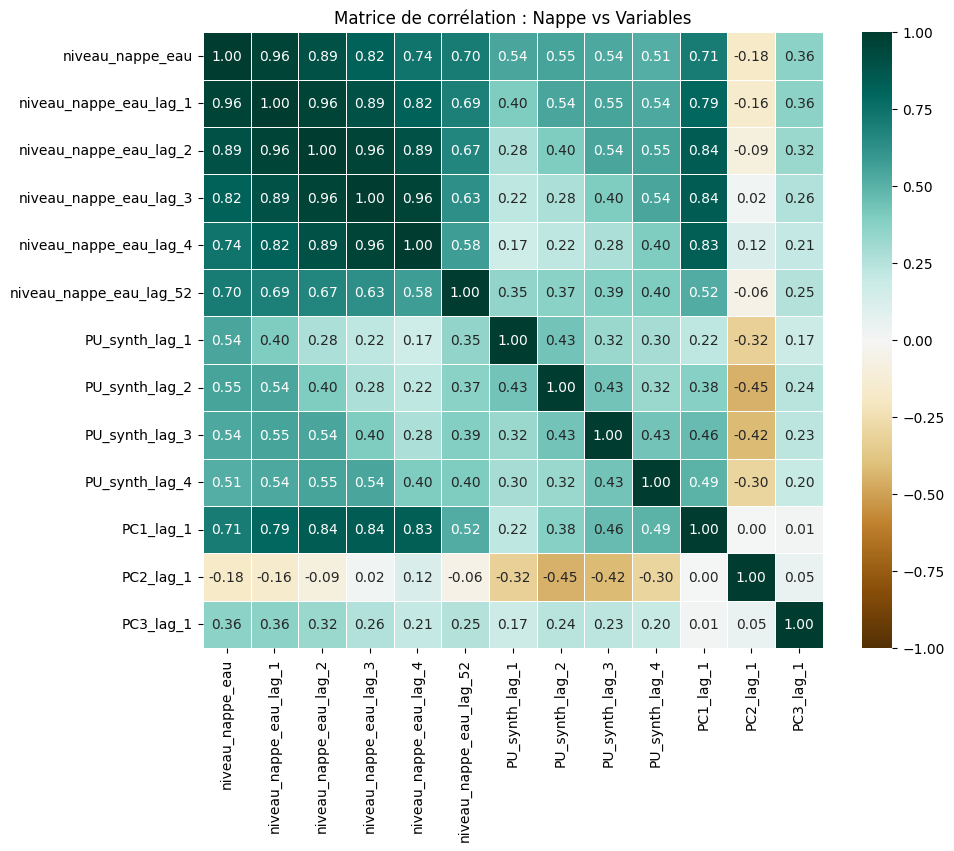

In [ ]:
# 1. Calcul de la matrice de corrélation
df_lagged = prepare_lags(df_plean)
df_lagged = df_lagged.join(df_plean[[TARGET_COL]], how= "left", on= 'date_mesure')

cols_to_corr_lagged = [TARGET_COL, 'niveau_nappe_eau_lag_1', 'niveau_nappe_eau_lag_2',
        'niveau_nappe_eau_lag_3', 'niveau_nappe_eau_lag_4', 'niveau_nappe_eau_lag_52',
        'PU_synth_lag_1', 'PU_synth_lag_2', 'PU_synth_lag_3', 'PU_synth_lag_4',
        'PC1_lag_1', 'PC2_lag_1', 'PC3_lag_1'
        ]



corr_mat = df_lagged[cols_to_corr_lagged].corr()

# 2. Configuration de la figure
plt.figure(figsize=(10, 8))

# 3. Création de la Heatmap
sns.heatmap(
    corr_mat,
    vmin=-1,
    vmax=1,
    cmap='BrBG',
    linewidths=.5,
    annot=True,
    annot_kws={"size": 10},
    fmt=".2f" # Pour limiter à 2 décimales et garder la lisibilité
)

plt.title("Matrice de corrélation : Nappe vs Variables")
plt.show()